<a href="https://colab.research.google.com/github/elijahmflomo/Sem_2_ADVANCED-REINFORCEMENT-LEARNING/blob/main/Assignment_Number_06_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Q-Learning on FrozenLake Environment using OpenAI Gym**

Aim

To implement Q-learning from scratch on the FrozenLake-v1 environment and analyze learning using reward and epsilon decay plots.

Problem Description

The agent is placed on a 4×4 frozen lake grid:

S → Start
F → Frozen (safe)
H → Hole (terminal, reward = 0)
G → Goal (reward = 1)

The environment is stochastic (slippery):

The agent may not move in the intended direction.
Task Summary
Use FrozenLake-v1 (4×4, slippery=True)
Implement Q-learning
Train for 5000 episodes
Plot:
Reward vs Episodes
Epsilon decay
Display final Q-table

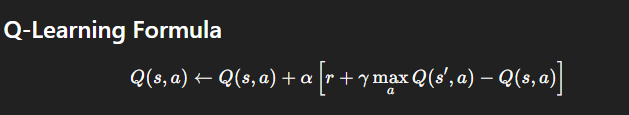

In [6]:
# Install gymnasium if not already installed
!pip install gymnasium

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# Create environment
env = gym.make("FrozenLake-v1", is_slippery=True)

# Parameters
episodes = 5000
alpha = 0.8
gamma = 0.95

epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995

# Initialize Q-table
state_size = env.observation_space.n
action_size = env.action_space.n

Q = np.zeros((state_size, action_size))

rewards = []
epsilons = []

In [7]:
# Training loop
for ep in range(episodes):
    state, _ = env.reset() # env.reset() returns (observation, info) with new_step_api=True
    done = False
    total_reward = 0

    while not done:
        # ε-greedy policy
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state])

        next_state, reward, terminated, truncated, _ = env.step(action) # new_step_api=True returns 5 values
        done = terminated or truncated # 'done' in old API is now 'terminated or truncated'

        # Q-learning update
        Q[state, action] += alpha * (
            reward + gamma * np.max(Q[next_state]) - Q[state, action]
        )

        state = next_state
        total_reward += reward

    # Decay epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    rewards.append(total_reward)
    epsilons.append(epsilon)

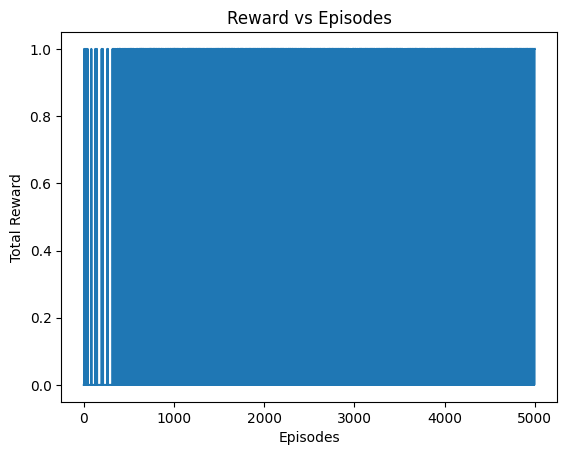

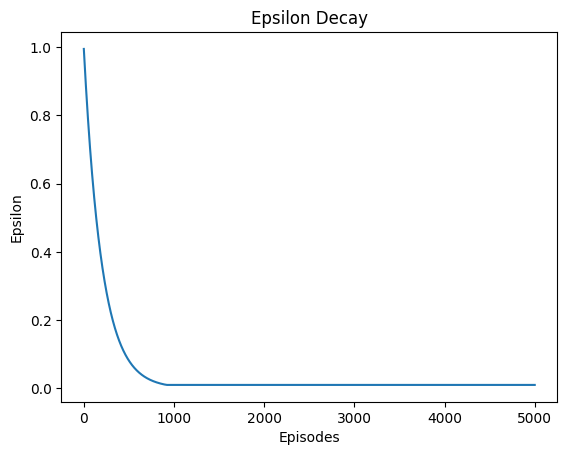

Final Q-table:
[[2.61638016e-01 5.55764189e-02 4.00025360e-02 4.73495407e-02]
 [1.38941969e-02 5.86955327e-03 1.19390388e-02 5.28912195e-02]
 [7.55750299e-03 3.21052162e-02 1.83737534e-02 2.68145633e-02]
 [6.01485514e-03 4.47958543e-03 3.11581542e-03 2.53682552e-02]
 [4.32852237e-01 6.74029909e-02 5.10742714e-02 3.10849329e-02]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [6.61221098e-02 1.83390596e-08 4.52931068e-05 2.53730022e-07]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.82908466e-02 1.02569170e-03 2.60555028e-01 6.28384452e-01]
 [3.03589120e-02 4.30981324e-01 2.02842401e-02 4.44207189e-02]
 [9.45221173e-01 1.96067222e-02 1.27596914e-03 1.70737017e-02]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.45157391e-04 1.19840394e-01 8.38762347e-01 1.16662413e-03]
 [1.94775045e-01 9.99920669e-01 2.49364474e-01 3.05637263e-01]
 [0.00000000e+00 0.00000000e+00 0.000000

In [10]:
# Plot 1: Reward vs Episodes
plt.plot(rewards)
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Reward vs Episodes")
plt.show()

# Plot 2: Epsilon decay
plt.plot(epsilons)
plt.xlabel("Episodes")
plt.ylabel("Epsilon")
plt.title("Epsilon Decay")
plt.show()

# Display Q-table
print("Final Q-table:")
print(Q)

**Effect of Learning Rate (α) on Q-Learning Performance**

Aim

To analyze how different learning rates (α) affect the performance of a Q-learning agent in terms of convergence speed and success rate.


**Problem Description**

A robotics engineer is deploying a navigation agent.
The agent’s performance depends on:

Learning rate (α)
Discount factor (γ)
Exploration rate (ε)

**We test three learning rates:**

α = 0.1
α = 0.5
α = 0.9


**Task Summary**
Train agent with 3 different α values
Keep γ and ε constant
Compare:
Convergence speed
Success rate
Plot all learning curves in one graph


**KEY IDEA**

Learning rate (α) controls:

α value	Behavior
Low (0.1)	Slow learning
Medium (0.5)	Balanced
High (0.9)	Fast but unstable

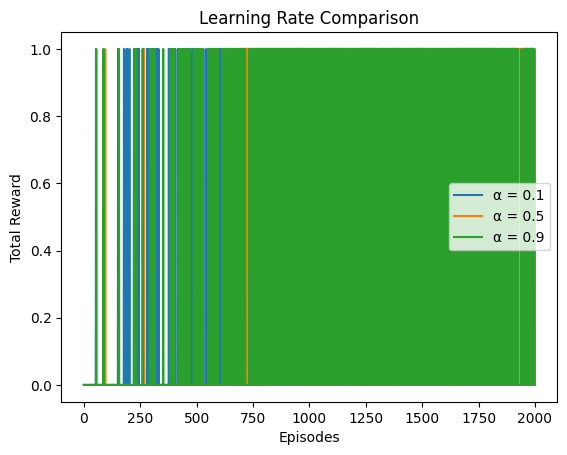

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

env = gym.make("FrozenLake-v1", is_slippery=True)

episodes = 2000
gamma = 0.95
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995

alphas = [0.1, 0.5, 0.9]
results = {}

for alpha in alphas:

    Q = np.zeros((env.observation_space.n, env.action_space.n))
    rewards = []
    eps = epsilon

    for ep in range(episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:

            # ε-greedy
            if np.random.rand() < eps:
                action = env.action_space.sample()
            else:
                action = np.argmax(Q[state])

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Q-learning update
            Q[state, action] += alpha * (
                reward + gamma * np.max(Q[next_state]) - Q[state, action]
            )

            state = next_state
            total_reward += reward

        eps = max(epsilon_min, eps * epsilon_decay)
        rewards.append(total_reward)

    results[alpha] = rewards

# Plot all curves
plt.figure()

for alpha in alphas:
    plt.plot(results[alpha], label=f'α = {alpha}')

plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Learning Rate Comparison")
plt.legend()
plt.show()

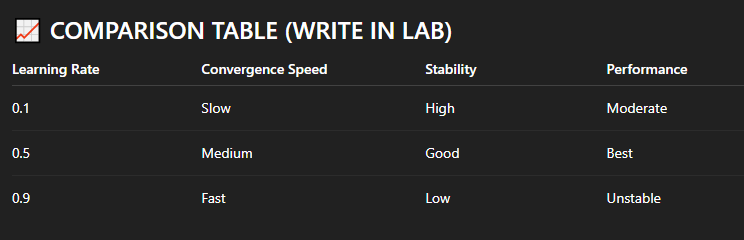

**Effect of Environmental Uncertainty on Q-Learning (FrozenLake)**

Aim

To study how stochastic (slippery) vs deterministic (non-slippery) environments affect Q-learning performance.


**Problem Description**

FrozenLake has two modes:

Type	Behavior
Slippery=True	Stochastic (random movement)
Slippery=False	Deterministic (exact movement)


**Task Summary**

Train Q-learning agent in both cases and compare:

Average reward
Convergence speed
Stability
Learned policy

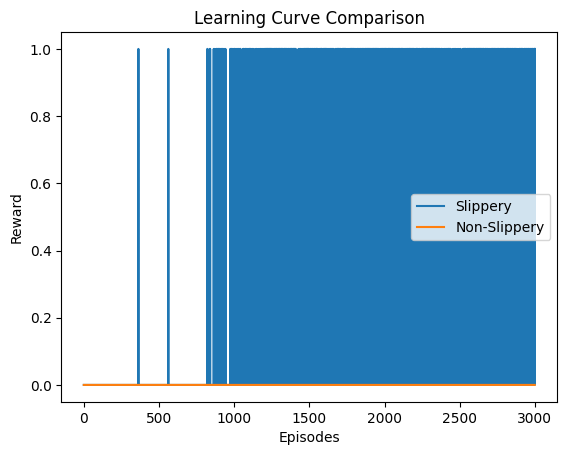

In [4]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

def train(env, episodes=3000):
    alpha = 0.8
    gamma = 0.95
    epsilon = 1.0
    epsilon_min = 0.01
    epsilon_decay = 0.995

    Q = np.zeros((env.observation_space.n, env.action_space.n))
    rewards = []

    for ep in range(episodes):
        state, _ = env.reset() # Using new Gymnasium API
        done = False
        total_reward = 0

        while not done:
            # ε-greedy
            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(Q[state])

            next_state, reward, terminated, truncated, _ = env.step(action) # Using new Gymnasium API
            done = terminated or truncated # 'done' in old API is now 'terminated or truncated'

            # Q-learning update
            Q[state, action] += alpha * (
                reward + gamma * np.max(Q[next_state]) - Q[state, action]
            )

            state = next_state
            total_reward += reward

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        rewards.append(total_reward)

    return Q, rewards

# Train both environments
env_slip = gym.make("FrozenLake-v1", is_slippery=True)
env_det = gym.make("FrozenLake-v1", is_slippery=False)

Q_slip, rewards_slip = train(env_slip)
Q_det, rewards_det = train(env_det)

# Plot learning curves
plt.plot(rewards_slip, label="Slippery")
plt.plot(rewards_det, label="Non-Slippery")
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.title("Learning Curve Comparison")
plt.legend()
plt.show()

POLICY EXTRACTION (ARROWS)

In [5]:
def get_policy(Q):
    arrows = ['←','↓','→','↑']
    policy = np.array([arrows[np.argmax(Q[s])] for s in range(Q.shape[0])])
    return policy.reshape(4,4)

print("Slippery Policy:")
print(get_policy(Q_slip))

print("\nNon-Slippery Policy:")
print(get_policy(Q_det))

Slippery Policy:
[['←' '↑' '←' '↓']
 ['←' '←' '←' '←']
 ['↑' '↓' '←' '←']
 ['←' '→' '→' '←']]

Non-Slippery Policy:
[['←' '←' '←' '←']
 ['←' '←' '←' '←']
 ['←' '←' '←' '←']
 ['←' '←' '←' '←']]


The non-slippery environment leads to faster convergence, higher rewards, and more stable learning due to deterministic transitions. In contrast, the slippery environment introduces uncertainty, resulting in slower learning, lower rewards, and fluctuating performance.